# **THE QUANTUM ALGORITHM ZOO**
---
<img src="Imperial_logo.png" align = "left" width=200>
 <br>
 
- Copyright (c) Jack Jacquier, 2026. All rights reserved

- Author: Jack Jacquier <a.jacquier@imperial.ac.uk>

- Platform: Tested on Windows 10 with Python 3.9
---

*PS: title freely borrowed from the website https://quantumalgorithmzoo.org*

In [1]:
#initialization
import matplotlib.pyplot as plt
import numpy as np
# importing Qiskit
from qiskit import QuantumCircuit, QuantumRegister
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from math import comb

$$\newcommand{\xx}{\mathrm{x}}$$
$$\newcommand{\RR}{\mathbb{R}}$$
$$\newcommand{\yy}{\mathrm{y}}$$
$$\newcommand{\Ff}{\mathcal{F}}$$
$$\newcommand{\Ffq}{{}_{\mathrm{q}}\Ff}$$
$$\newcommand{\Id}{\mathrm{I}}$$
$$\newcommand{\Ug}{\mathtt{U}}$$

# Quantum Fourier Transform (Coppersmith, 1994)

The classical Fourier transform corresponds to the map $\xx\in\RR^N\mapsto \yy \in\RR^N$, where
$$
y_j := \frac{1}{\sqrt{N}}\sum_{k=0}^{N-1}x_k \exp\left\{\frac{2\I \pi kj}{N}\right\}, 
\qquad \text{for }j=0,\ldots, N-1.
$$
The quantum counterpart is the map
$$
\Ffq := \frac{1}{\sqrt{N}}\sum_{j,k=0}^{N-1}\exp\left\{\frac{2\I \pi jk}{N}\right\}\ket{k}\bra{j}
$$ 
so that, for a given $j \in \{0, \ldots, N-1\}$,
$$
\Ffq\ket{j} = \frac{1}{\sqrt{N}}\sum_{k=0}^{N-1}\exp\left\{\frac{2\I \pi kj}{N}\right\}\ket{k},
$$
and for an arbitrary quantum state $\ket{\psi} := \sum_{j=0}^{N-1}x_j \ket{j}$, we have
$$
\Ffq\ket{\psi}
= \frac{1}{\sqrt{N}}\sum_{j=0}^{N-1}x_j\sum_{k=0}^{N-1}\exp\left\{\frac{2\I \pi kj}{N}\right\}\ket{k}
= \frac{1}{\sqrt{N}}\sum_{j,k=0}^{N-1}\exp\left\{\frac{2\I \pi kj}{N}\right\}x_j\ket{k}.
$$

*Exercise:* Show that the quantum Fourier transform map is unitary, i.e. $\Ffq*\Ffq^{\dagger}=\Id$.

### Implementation

In [2]:
def qft(qc, n):
    """
    Apply Quantum Fourier Transform to a given circuit composed of n_qubits qubits
    qc: quantum circuit
    n: number of qubits
    """

    for j in range(n):
        qc.h(j)
        for m in range(j+1,n):
            qc.cp(-np.pi/float(2**(j-m)), m, j)
        qc.barrier()
        
    ### Do not forget the SWAP gates!!
    
    for q in range(n//2):
        qc.swap(q, n-q-1)
    return qc

def qft_dagger(qc, n):
    """
    Apply Inverse (dagger since unitary) Quantum Fourier Transform to a given circuit composed of n_qubits qubits
    qc: quantum circuit
    n: number of qubits
    """
    
    ### Do not forget the SWAP gates!!
    
    for q in range(n//2):
        qc.swap(q, n-q-1)
    qc.barrier()
    
    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi/float(2**(j-m)), m, j)
        qc.h(j)
        qc.barrier()
    return qc

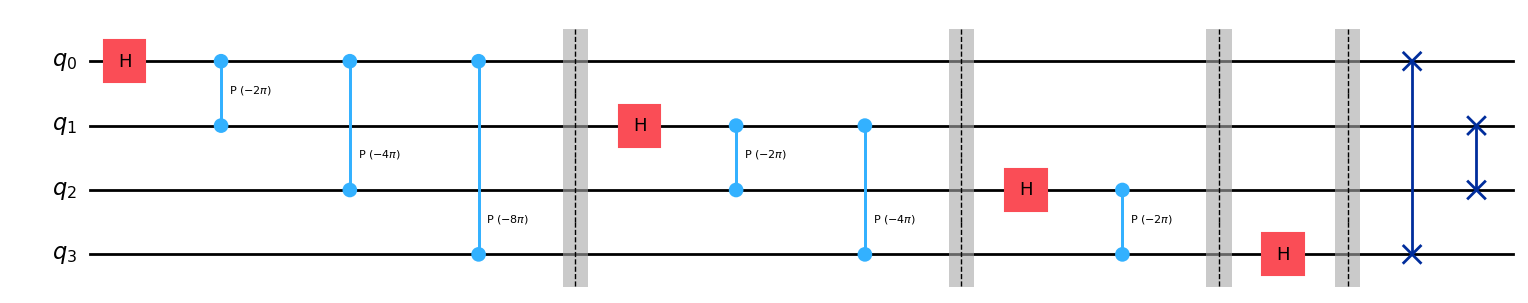

In [3]:
nb_qubits = 4 ## number of qubits
qc = QuantumCircuit(nb_qubits)
qc = qft(qc, nb_qubits)
qc.draw('mpl')

**TOTAL COST:**
- $\sum_{k=0}^{n}k = \frac{n(n+1)}{2}$ gates to generate the quantum state before the SWAP gates.
- The SWAP operation requires at most $\frac{n}{2}$;
- Each SWAP gate can be realised with three CNOT gates;
- TOTAL: $\frac{n(n+1)}{2} + \frac{3n}{2} = \mathcal{O}(n^2)$ for large $n$.

**CLASSICAL COST (for a vector of size $N$):**
- Discrete Fourier transform: $\mathcal{O}(N^2)$;
- Fast Fourier transform: $\mathcal{O}(N\log(N))$.

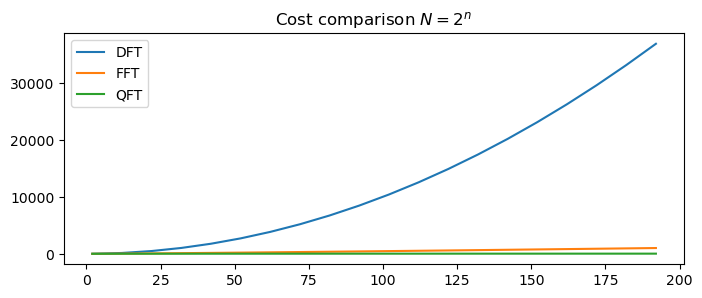

In [4]:
def dft(N):
    return N*N

def fft(N):
    return N*np.log(N)

def qft(N):
    n = np.log(N)
    return n*(n+1)/2 + 3*n/2

NN = np.arange(2, 200, 10)
plt.figure(figsize=(8,3))
plt.plot(NN, dft(NN), label="DFT")
plt.plot(NN, fft(NN), label="FFT")
plt.plot(NN, qft(NN), label="QFT")
plt.legend(loc="best")
plt.title("Cost comparison $N = 2^n$")
plt.show()

**COMMENTS/REMARKS/WARNINGS**

# Quantum Phase Estimation (Kitaev, 1995)

$$
\textbf{GOAL: }\qquad\text{Given a quantum state }
\quad \frac{1}{\sqrt{2^n}}\sum_{y=0}^{2^n-1}\mathrm{e}^{2\mathrm{i} \pi\omega y}\ket{y},
\quad \text{ obtain a good estimate for } \omega.
$$

**Method:** Relies on (inverse) QFT.

# ERROR CORRECTION

## Classical Error correction

We consider a classical bit $B$, taking values in $\{0,1\}$, that is transmitted through a channel.
This channel is noisy though, and there is a probability $\mathfrak{p}\in (0,1)$ that $B$ gets flipped.

We then adopt the following strategy: we make $2m+1$ (independent) copies of $B$ and use the *majority rule*, namely take as result whichever bit appears most often.

The probability that exactly $i \in \{0,\ldots,2m+1\}$ bits are flipped is equal to
$$
\mathbb{P}_{i} := \begin{pmatrix}
2m+1\\
i
\end{pmatrix}
\mathfrak{p}^i (1-\mathfrak{p})^{2m+1-i},
$$
and therefore the probability that exactly at most $m \in \{0,\ldots,2m+1\}$ bits are flipped is equal to
$$
\sum_{i=0}^{m}\mathbb{P}_{i}.
$$

In [5]:
def probaError(p, m):
    """
    p: probability of a bit being flipped
    m: positive integer
    2m+1: number of bits sent

    returns the probability that more than m+1 bits are flipped
    """
    output = 0
    for i in range(m+1, 2*m+2):
        output += comb(2*m+1, i)*p**(i) * (1-p)**(2*m+1-i)
    return output

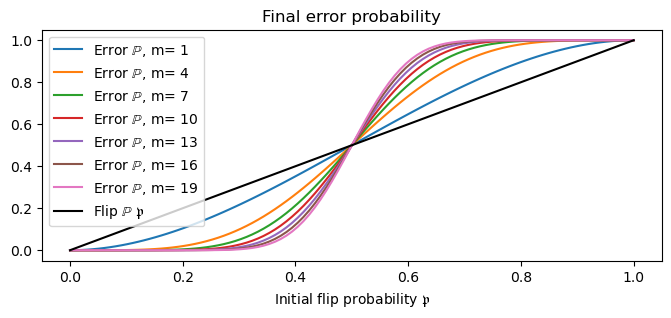

In [6]:
pp = np.linspace(0., 1., 100)
plt.figure(figsize=(8,3))
for m in np.arange(1, 20, 3):
    plt.plot(pp, [probaError(p, m) for p in pp], label=r'Error $\mathbb{P}$, m= %s' %str(m))
plt.plot(pp, [p for p in pp], 'k', label=r'Flip $\mathbb{P}$ $\mathfrak{p}$')
plt.xlabel(r'Initial flip probability $\mathfrak{p}$')
plt.legend(loc="best")
plt.title("Final error probability")
plt.show()

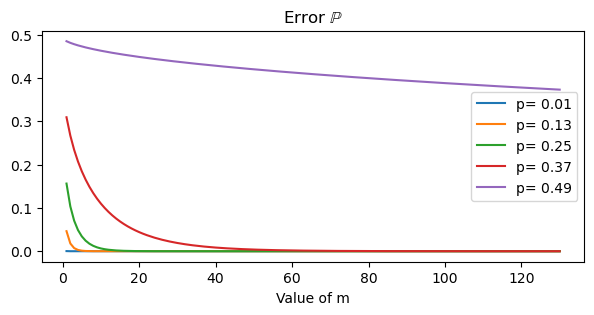

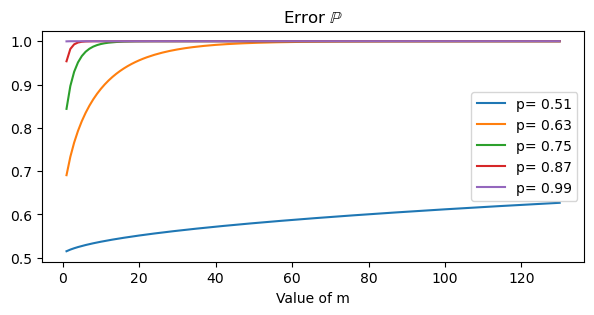

In [7]:
mm = np.arange(1, 131)
plt.figure(figsize=(7,3))
for p in np.linspace(0.01, .49, 5):
    plt.plot(mm, [probaError(p, m) for m in mm], label=r'p= %.2f' %p)
plt.xlabel("Value of m")
plt.legend(loc="best")
plt.title(r'Error $\mathbb{P}$')
plt.show()

plt.figure(figsize=(7,3))
for p in np.linspace(0.51, .99, 5):
    plt.plot(mm, [probaError(p, m) for m in mm], label=r'p= %.2f' %p)
plt.xlabel("Value of m")
plt.legend(loc="best")
plt.title(r'Error $\mathbb{P}$')
plt.show()

### Terminology:
[n,k,d] represents the encoding of k logical bits into n physical bits with (Hamming) code distance d: any logical operation requires flipping at least d bits, equivalently many bit errors the system can detect or correct.


In the example above,
- n = 2m+1 (block length): total number of bits in the transmitted message. 
- k = 1 (message length): number of actual, data bits we want to send. 
- d = 3 (Hamming distance): how many bits change between valid code words. The only two valid code words are 000 (for a 0) and 111 (for a 1). These two options differ by exactly 3 bit.

## Quantum Error Correction

**No-cloning Theorem**

For any $n\geq 2$, there does not exist a quantum circuit $\Ug$ such that, for any 1-qubit states $\ket{\psi}$ and $\ket{\phi}$,
\begin{align*}
\Ug\ket{\psi}\ket{0} & = \ket{\psi}\otimes\ket{\psi},\\
\Ug\ket{\phi}\ket{0} & = \ket{\phi}\otimes\ket{\phi}.
\end{align*}

### Simple correction and implications

Given a one-qubit quantum state $\ket{\psi} = \alpha\ket{0} + \beta\ket{1}$, with unknown amplitudes $\alpha$ and $\beta$, we can construct the three-qubit state
$$
\ket{\Psi} = \alpha\ket{000} + \beta\ket{111}
$$
via the following quantum circuit:


In [19]:
def qec(theta, qmeasureAll=True):
    """
    Quantum Error correction simple
    theta: rotation angle to create the initial state
    qmeasureAll: if True, measure all, else only the first qubit
    """
    
    if qmeasureAll:
        qc = QuantumCircuit(3)
        qc.rx(theta, 0)
        qc.cx(0, 1)
        qc.cx(0, 2)
        qc.measure_all()
    else:
        qc = QuantumCircuit(1)
        qc.rx(theta, 0)
        qc.measure_all()
        
    return qc

The following circuit, `qc_all` generates a quantum state
$\alpha\ket{0} + \beta\ket{1} := \mathtt{R}_{\mathtt{X}}(\theta)\ket{0}$ for some $\theta \in [0,2\pi]$, construct $\alpha\ket{000} + \beta\ket{111}$ and measure all the qubits.

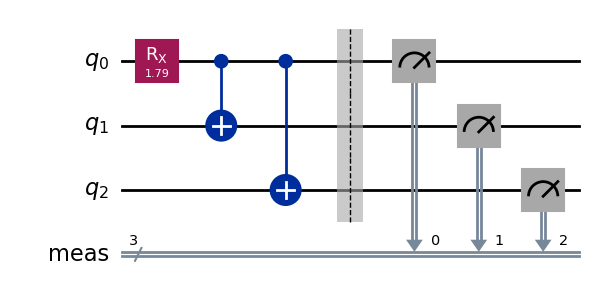

In [20]:
theta = 2.*np.pi*np.random.rand()
qc_all = qec(theta, qmeasureAll=True)
qc_all.draw('mpl')

The following circuit, `qc0` does the same, but only measures qubit 0.

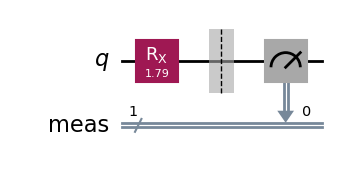

In [21]:
qc0 = qec(theta, qmeasureAll=False)
qc0.draw('mpl')

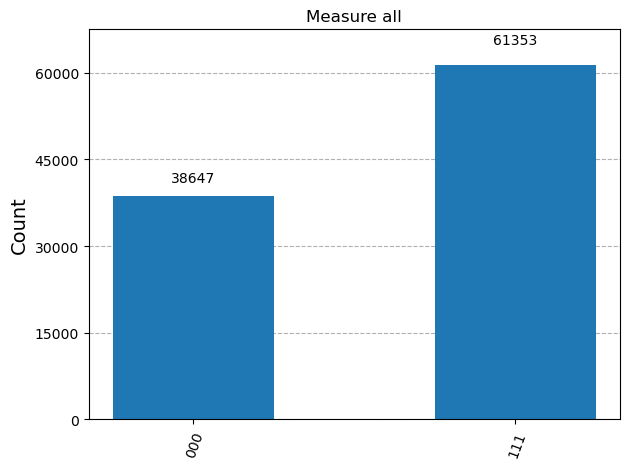

In [22]:
backend = Aer.get_backend('qasm_simulator')
shots = 100000
results = backend.run(qc_all, shots=shots).result()
answer = results.get_counts()
plot_histogram(answer, title="Measure all")

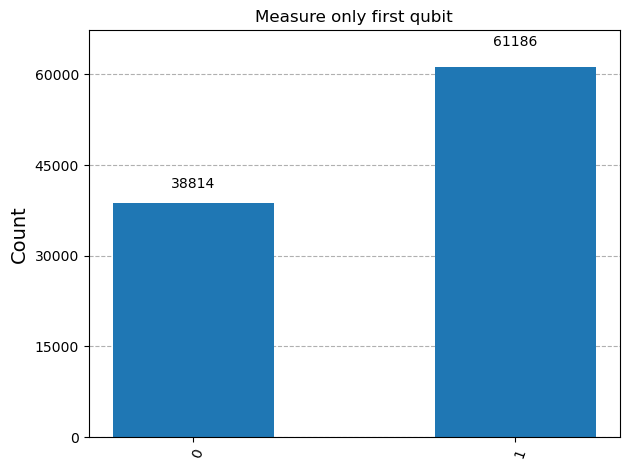

In [24]:
backend = Aer.get_backend('qasm_simulator')
shots = 100000
results = backend.run(qc0, shots=shots).result()
answer = results.get_counts()
plot_histogram(answer, title="Measure only first qubit")

## Mimicking classical error correction

Consider now the measurement operators:
\begin{align*}
\mathbb{P}_{0} & \quad := \quad \ket{000}\bra{000} \quad + \quad  \ket{111}\bra{111} \qquad \text{no error}, \\
\mathbb{P}_{1} & \quad := \quad \ket{100}\bra{100} \quad + \quad  \ket{011}\bra{011} \qquad \text{bit flip on qubit 1},\\
\mathbb{P}_{2} & \quad := \quad \ket{010}\bra{010} \quad + \quad  \ket{101}\bra{101} \qquad \text{bit flip on qubit 2},\\
\mathbb{P}_{3} & \quad := \quad \ket{001}\bra{001} \quad + \quad  \ket{110}\bra{110} \qquad \text{bit flip on qubit 3}.
\end{align*}

This implies in particular that
- If no bit flip occurs, then the uncorrupted state reads $\boldsymbol{\ket{\phi_{0}}=\ket{\psi}}$. In this case, the different measurements read (by Born's rule):
$$
\braket{\phi_{0}|\mathbb{P}_{0}|\phi_{0}}\  = 1
\qquad\text{and}\qquad
\braket{\phi_{0}|\mathbb{P}_{1}|\phi_{0}}\  
= \braket{\phi_{0}|\mathbb{P}_{2}|\phi_{0}}\  
= \braket{\phi_{0}|\mathbb{P}_{3}|\phi_{0}}\  = 0.
$$
- If the bit flip occurs on qubit 1, then the corrupted state reads $\boldsymbol{\ket{\phi_{1}}:=\alpha\ket{100} + \beta\ket{011}}$. In this case, the different measurements read (by Born's rule):
$$
\braket{\phi_{1}|\mathbb{P}_{1}|\phi_{1}}\  = 1
\qquad\text{and}\qquad
\braket{\phi_{1}|\mathbb{P}_{0}|\phi_{1}}\  
= \braket{\phi_{1}|\mathbb{P}_{2}|\phi_{1}}\  
= \braket{\phi_{1}|\mathbb{P}_{3}|\phi_{1}}\  = 0.
$$
- If the bit flip occurs on qubit 2, then the corrupted state reads $\boldsymbol{\ket{\phi_{2}}:=\alpha\ket{010} + \beta\ket{101}}$. In this case, the different measurements read (by Born's rule):
$$
\braket{\phi_{2}|\mathbb{P}_{2}|\phi_{2}}\  = 1
\qquad\text{and}\qquad
\braket{\phi_{2}|\mathbb{P}_{0}|\phi_{2}}\  
= \braket{\phi_{2}|\mathbb{P}_{1}|\phi_{2}}\  
= \braket{\phi_{2}|\mathbb{P}_{3}|\phi_{2}}\  = 0.
$$

- If the bit flip occurs on qubit 3, then the corrupted state reads $\boldsymbol{\ket{\phi_{3}}:=\alpha\ket{001} + \beta\ket{110}}$. In this case, the different measurements read (by Born's rule):
$$
\braket{\phi_{3}|\mathbb{P}_{3}|\phi_{3}}\  = 1
\qquad\text{and}\qquad
\braket{\phi_{3}|\mathbb{P}_{0}|\phi_{3}} \ 
= \braket{\phi_{3}|\mathbb{P}_{1}|\phi_{3}}\  
= \braket{\phi_{3}|\mathbb{P}_{2}|\phi_{3}}\ 
= 0.
$$

**Note:** these measurements do not affect the amplitude coefficients $\alpha$ and $\beta$, but only detect which qubit has been affected.

Depending on the outcomes, we can then recover the original state using an $\mathtt{X}$ gate on the corresponding qubit.

**Exercise:** show that this procedure reduces the error probability as in the classical error correction case.

**Terminology:**
[[n,k,d]]: quantum code that encodes k logical qubits into n physical qubits with code distance d.

# APPLICATIONS

## HHL algorithm (Harrow-Hassidim-Lloyd, 2008)

**GOAL:** Solve a system of $N$ linear equations $\mathrm{A}\mathrm{x} = \mathrm{b} \in \mathbb{R}^{N}$

**Cost:** $\mathcal{O}(\log(N)\kappa^2)$, where $\kappa$ is the condition number of the matrix $\mathrm{A}$.

**Classical Cost:** $\mathcal{O}(N \kappa)$, where $\kappa$ is the condition number of the matrix $\mathrm{A}$.

**Limitations:**
- First step: transform $\mathrm{b} \longrightarrow \ket{\mathrm{b}}$: can be very costly;
- Uses QPE;
- The output state $\ket{\mathrm{x}}$ is not directly accessible.

## Schor's algorithm (Schor, 1994)

**GOAL:** Find the prime factors of an integer, developed in 1994 by Peter Shor.

**Application:** Breaking security-standard RSA encryption. 

**Theoretical advantage:** Exponential speedup

**Limitations:** 
- Based on Quantum Phase Estimation
- Requires millions of physical qubits and thousands of logical qubits.


## Grover's (Quantum search) algorithm (Grover, 1996)

**GOAL:** search a unique value through unstructured data with high probability.

**Applications:** 
- Sub-routine to speed up many algorithms
- Cryptography: Find $x$ such that $f(x)=y$

**Theoretical advantage:** $\mathcal{O}(\sqrt{N})$ vs classical $\mathcal{O}(N)$.

**Limitations:** 
- The promised quadratic speedup is still limited by large quantum overheads.

# Key takeaways

- Many of these algorithms rely on the Quantum Fourier Transform which provides speedup, but requires full connectivity and many gates.
- Do we need full QFT though? Some approximations may be efficient.